In [ ]:
import pandas as pd
import numpy as np

In [5]:
data=pd.read_csv('QVI_data.csv')
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150.0,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210.0,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175.0,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160.0,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [6]:
data.shape

(87750, 12)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87750 entries, 0 to 87749
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LYLTY_CARD_NBR    87750 non-null  int64  
 1   DATE              87750 non-null  object 
 2   STORE_NBR         87750 non-null  int64  
 3   TXN_ID            87750 non-null  int64  
 4   PROD_NBR          87750 non-null  int64  
 5   PROD_NAME         87750 non-null  object 
 6   PROD_QTY          87750 non-null  int64  
 7   TOT_SALES         87750 non-null  float64
 8   PACK_SIZE         87749 non-null  float64
 9   BRAND             87749 non-null  object 
 10  LIFESTAGE         87749 non-null  object 
 11  PREMIUM_CUSTOMER  87749 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 8.0+ MB


In [8]:
data.isnull().sum()

,0
LYLTY_CARD_NBR,0
DATE,0
STORE_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,1
BRAND,1


In [9]:
data['DATE'] = pd.to_datetime(data['DATE'])

In [10]:
data['MONTH'] = data['DATE'].dt.to_period('M')

In [11]:
group = data.groupby(['STORE_NBR', 'MONTH'])

In [12]:
group.agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'nunique'
})

TOT_SALES  LYLTY_CARD_NBR  TXN_ID
STORE_NBR MONTH                                     
1         2018-07      206.9              49      52
          2018-08      176.1              42      43
          2018-09      278.8              59      62
          2018-10      188.1              44      45
          2018-11      192.6              46      47
...                      ...             ...     ...
91        2019-03      170.3              19      21
          2019-04      279.0              28      33
          2019-05      288.5              27      33
          2019-06      261.0              26      31
155       2019-06       16.8               2       2

[1050 rows x 3 columns]

In [13]:
store_monthly_data = group.agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'nunique'
})

In [14]:
store_monthly_data = store_monthly_data.rename(columns={
    'TOT_SALES': 'SALES',
    'LYLTY_CARD_NBR': 'CUSTOMERS',
    'TXN_ID': 'TRANSACTIONS'
})

In [15]:
store_monthly_data['TXN_PER_CUSTOMER'] = (
    store_monthly_data['TRANSACTIONS'] / store_monthly_data['CUSTOMERS']
)

In [16]:
store_monthly_data = store_monthly_data.reset_index()

In [17]:
store_monthly_data.head()

,STORE_NBR,MONTH,SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


In [18]:
trial_stores_data = store_monthly_data[
    store_monthly_data['STORE_NBR'].isin([77, 86, 88])
]
other_stores_data = store_monthly_data[
    ~store_monthly_data['STORE_NBR'].isin([77, 86, 88])
]

In [19]:
trial_stores_data['STORE_NBR'].unique()

array([77, 86, 88])

In [20]:
store_monthly_data['MONTH'].sort_values().unique()

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01',
 '2019-02', '2019-03', '2019-04', '2019-05', '2019-06']
Length: 12, dtype: period[M]

In [21]:
pre_trial_data = store_monthly_data[
    store_monthly_data['MONTH'] < '2019-02'
]

In [22]:
pre_trial_data['MONTH'].unique()

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]

In [23]:
store_77 = pre_trial_data[pre_trial_data['STORE_NBR'] == 77]
store_77 = store_77.sort_values('MONTH')

In [24]:
store_10 = pre_trial_data[pre_trial_data['STORE_NBR'] == 10]
store_10 = store_10.sort_values('MONTH')

In [25]:
print(store_77['MONTH'].values)
print(store_10['MONTH'].values)

[Period('2018-07', 'M') Period('2018-08', 'M') Period('2018-09', 'M')
 Period('2018-10', 'M') Period('2018-11', 'M') Period('2018-12', 'M')
 Period('2019-01', 'M')]
[Period('2018-07', 'M') Period('2018-08', 'M') Period('2018-09', 'M')
 Period('2018-10', 'M') Period('2018-11', 'M') Period('2018-12', 'M')
 Period('2019-01', 'M')]


In [26]:
store_77['SALES'].corr(store_10['SALES'])

nan

In [27]:
print(store_77['SALES'])
print(store_10['SALES'])

880    272.3
881    255.5
882    206.2
883    204.5
884    207.6
885    267.3
886    204.4
Name: SALES, dtype: float64
108    892.00
109    878.65
110    945.00
111    910.80
112    885.00
113    936.60
114    878.60
Name: SALES, dtype: float64


In [28]:
store_77_sales = store_77['SALES'].reset_index(drop=True)
store_10_sales = store_10['SALES'].reset_index(drop=True)

store_77_sales.corr(store_10_sales)

np.float64(-0.0018580625909750367)

In [31]:
correlations = []

for store in pre_trial_data['STORE_NBR'].unique():

    if store == 77:
        continue

    trial = pre_trial_data[pre_trial_data['STORE_NBR'] == 77].sort_values('MONTH')
    control = pre_trial_data[pre_trial_data['STORE_NBR'] == store].sort_values('MONTH')

    if len(trial) == len(control):

        trial_sales = trial['SALES'].reset_index(drop=True)
        control_sales = control['SALES'].reset_index(drop=True)

        trial_customers = trial['CUSTOMERS'].reset_index(drop=True)
        control_customers = control['CUSTOMERS'].reset_index(drop=True)

        trial_txn = trial['TXN_PER_CUSTOMER'].reset_index(drop=True)
        control_txn = control['TXN_PER_CUSTOMER'].reset_index(drop=True)

        corr_sales = trial_sales.corr(control_sales)
        corr_customers = trial_customers.corr(control_customers)
        corr_txn = trial_txn.corr(control_txn)

        # Ignore NaN values
        avg_corr = np.nanmean([corr_sales, corr_customers, corr_txn])

        correlations.append((store, avg_corr))


correlations = sorted(correlations, key=lambda x: x[1], reverse=True)

print(correlations[:5])

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:292

[(np.int64(3), np.float64(0.7723927037675579)), (np.int64(37), np.float64(0.7579859109762298)), (np.int64(84), np.float64(0.6903450762852762)), (np.int64(33), np.float64(0.6367946929561873)), (np.int64(71), np.float64(0.5793826307719019))]


In [32]:
trial_period_data = store_monthly_data[
    store_monthly_data['MONTH'] >= '2019-02'
]

In [33]:
trial_77 = trial_period_data[trial_period_data['STORE_NBR'] == 77]
control_3 = trial_period_data[trial_period_data['STORE_NBR'] == 3]

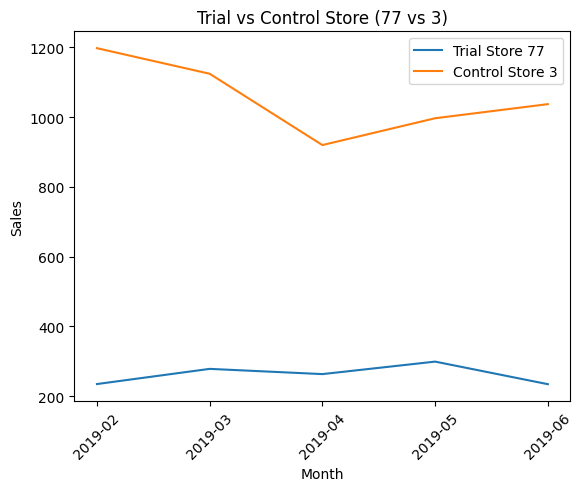

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(trial_77['MONTH'].astype(str), trial_77['SALES'], label='Trial Store 77')
plt.plot(control_3['MONTH'].astype(str), control_3['SALES'], label='Control Store 3')

plt.xticks(rotation=45)
plt.legend()
plt.title('Trial vs Control Store (77 vs 3)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()